# Actividad 04 - B: Dataset Sintético MOONS
**Universidad Nacional del Altiplano Puno**  
Aprendizaje de Máquina - IX ciclo, Grupo B

| | |
|---|---|
| **Modelos** | KMeans, DBSCAN, SpectralClustering |
| **Métricas Externas** | Adjusted Rand Index (ARI), V-Measure |
| **Métricas Internas** | Silhouette Score, Davies-Bouldin Index, Elbow Method |


In [ ]:
# Instalar dependencias (solo necesario en Colab)
# !pip install scikit-learn matplotlib numpy -q


## 1. Importar librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import (
    adjusted_rand_score, v_measure_score,
    silhouette_score, davies_bouldin_score,
)


## 2. Cargar y preprocesar el dataset

In [ ]:
X_raw, y_true = make_moons(n_samples=300, noise=0.08, random_state=42)
X = StandardScaler().fit_transform(X_raw)

print(f"Muestras   : {X.shape[0]}")
print(f"Características: {X.shape[1]}")
print(f"Clases reales  : 2  (luna 0 / luna 1)")


Muestras   : 300
Características: 2
Clases reales  : 2  (luna 0 / luna 1)


### Distribución real del dataset MOONS

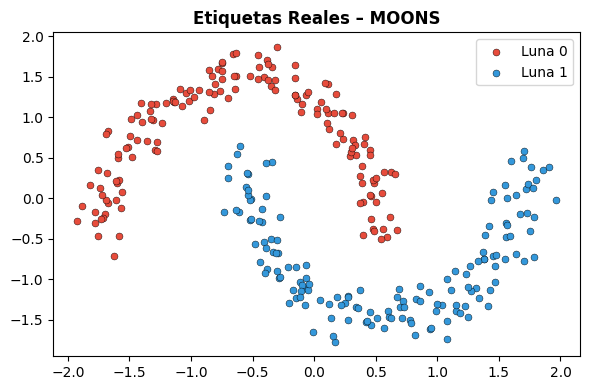

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#E74C3C', '#3498DB']
for i, lbl in enumerate(['Luna 0', 'Luna 1']):
    ax.scatter(X[y_true == i, 0], X[y_true == i, 1],
               c=colors[i], label=lbl, s=25, edgecolors='k', linewidths=0.3)
ax.set_title("Etiquetas Reales – MOONS", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## **OPTIMIZACION DE HIPERPARAMETROS**

**1. Grid search para K-means**

In [ ]:
# OPTIMIZACIÓN K-MEANS
print("\n=== OPTIMIZACIÓN K-MEANS ===")
k_range = range(2, 6)
results_km = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    results_km.append({
        'k': k,
        'ARI': adjusted_rand_score(y_true, labels),
        'V-measure': v_measure_score(y_true, labels),
        'Silhouette': silhouette_score(X, labels),
        'Davies-Bouldin': davies_bouldin_score(X, labels)
    })
df_km = pd.DataFrame(results_km)
print(df_km.to_string(index=False))
best_k = df_km.loc[df_km['ARI'].idxmax(), 'k']
print(f"\nMejor k: {int(best_k)}")


=== OPTIMIZACIÓN K-MEANS ===
 k      ARI  V-measure  Silhouette  Davies-Bouldin
 2 0.478969   0.381881    0.493630        0.805568
 3 0.362949   0.328796    0.434991        0.888325
 4 0.296928   0.339216    0.416207        0.949145
 5 0.301276   0.446271    0.447768        0.753517

Mejor k: 2


2. **Grid search para DBSCAN**

In [ ]:
# OPTIMIZACIÓN DBSCAN
print("\n=== OPTIMIZACIÓN DBSCAN ===")
eps_values = [0.1, 0.15, 0.2, 0.25, 0.3]
min_samples_values = [3, 5, 7, 10]
results_db = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters >= 2:
            sil = silhouette_score(X, labels) if n_clusters >= 2 else None
            results_db.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'ARI': adjusted_rand_score(y_true, labels),
                'V-measure': v_measure_score(y_true, labels),
                'Silhouette': sil,
                'Davies-Bouldin': davies_bouldin_score(X, labels)
            })
df_db = pd.DataFrame(results_db)
print(df_db.to_string(index=False))
best_db = df_db.loc[df_db['ARI'].idxmax()]
print(f"\nMejor: eps={best_db['eps']}, min_samples={int(best_db['min_samples'])}")


=== OPTIMIZACIÓN DBSCAN ===
 eps  min_samples  n_clusters      ARI  V-measure  Silhouette  Davies-Bouldin
0.10            3          30 0.059864   0.274457    0.033097        1.704170
0.10            5          15 0.034698   0.213872   -0.302163        1.407954
0.15            3          15 0.209047   0.408829    0.176182        2.188058
0.15            5          18 0.129114   0.351416    0.214270        2.091392
0.15            7          14 0.085851   0.298384    0.028739        1.821541
0.15           10           3 0.008546   0.127095   -0.364598        1.537423
0.20            3           8 0.550536   0.602671    0.134239        1.653316
0.20            5           7 0.543471   0.591650    0.191050        1.806661
0.20            7           6 0.541419   0.594445    0.185050        4.268209
0.20           10           7 0.213212   0.383951    0.135882        1.742764
0.25            3           2 0.993355   0.985761    0.242373        0.858707
0.25            5           2 0.986

3. **Grid search para Spectral**

In [ ]:
# OPTIMIZACIÓN SPECTRAL
print("\n=== OPTIMIZACIÓN SPECTRAL ===")
k_range = range(2, 5)
gamma_values = [0.5, 1.0, 2.0, 4.0]
results_sp = []

for k in k_range:
    for gamma in gamma_values:
        spectral = SpectralClustering(n_clusters=k, affinity='rbf', gamma=gamma, random_state=42)
        labels = spectral.fit_predict(X)
        results_sp.append({
            'k': k,
            'gamma': gamma,
            'ARI': adjusted_rand_score(y_true, labels),
            'V-measure': v_measure_score(y_true, labels),
            'Silhouette': silhouette_score(X, labels),
            'Davies-Bouldin': davies_bouldin_score(X, labels)
        })
df_sp = pd.DataFrame(results_sp)
print(df_sp.to_string(index=False))
best_sp = df_sp.loc[df_sp['ARI'].idxmax()]
print(f"\nMejor: k={int(best_sp['k'])}, gamma={best_sp['gamma']}")


=== OPTIMIZACIÓN SPECTRAL ===
 k  gamma      ARI  V-measure  Silhouette  Davies-Bouldin
 2    0.5 0.488289   0.390197    0.493571        0.805649
 2    1.0 0.516784   0.415926    0.492432        0.807241
 2    2.0 0.607086   0.500605    0.484103        0.820221
 2    4.0 0.761915   0.659576    0.456318        0.866548
 3    0.5 0.238203   0.232846    0.381237        0.962261
 3    1.0 0.304743   0.272161    0.374462        0.965894
 3    2.0 0.574491   0.529635    0.420283        0.761319
 3    4.0 0.512965   0.551500    0.382510        0.912474
 4    0.5 0.410452   0.462382    0.403672        0.778050
 4    1.0 0.416944   0.463723    0.401724        0.766116
 4    2.0 0.457800   0.503420    0.396194        0.763707
 4    4.0 0.537890   0.599294    0.374943        0.785245

Mejor: k=2, gamma=4.0


## 3. Entrenar los modelos de clustering

In [ ]:
# MODELOS OPTIMIZADOS
kmeans = KMeans(n_clusters=int(best_k), random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X)

dbscan = DBSCAN(eps=best_db['eps'], min_samples=int(best_db['min_samples']))
labels_db = dbscan.fit_predict(X)

spectral = SpectralClustering(n_clusters=int(best_sp['k']), affinity='rbf',
                               gamma=best_sp['gamma'], random_state=42)
labels_sp = spectral.fit_predict(X)

labels_dict = {
    "KMeans": labels_km,
    "DBSCAN": labels_db,
    "SpectralClustering": labels_sp
}

### Visualización de resultados por modelo

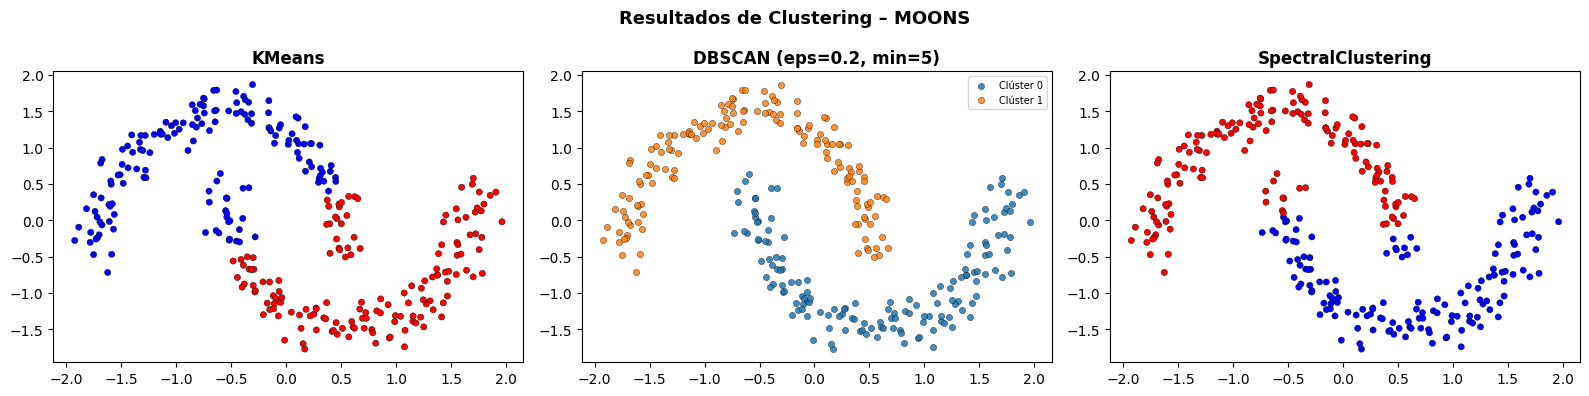

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = ["KMeans", "DBSCAN (eps=0.2, min=5)", "SpectralClustering"]
all_labels = [labels_km, labels_db, labels_sp]

for ax, title, lbl in zip(axes, titles, all_labels):
    if title.startswith("DBSCAN"):
        for k in sorted(set(lbl)):
            mask  = lbl == k
            color = 'gray' if k == -1 else f'C{k}'
            label = 'Ruido' if k == -1 else f'Clúster {k}'
            ax.scatter(X[mask, 0], X[mask, 1], c=color,
                       label=label, s=20, edgecolors='k', linewidths=0.3, alpha=0.85)
        ax.legend(fontsize=7)
    else:
        ax.scatter(X[:, 0], X[:, 1], c=lbl, cmap='bwr',
                   s=20, edgecolors='k', linewidths=0.3)
    ax.set_title(title, fontweight='bold')

plt.suptitle("Resultados de Clustering – MOONS", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Métrica Interna – Elbow Method (KMeans)

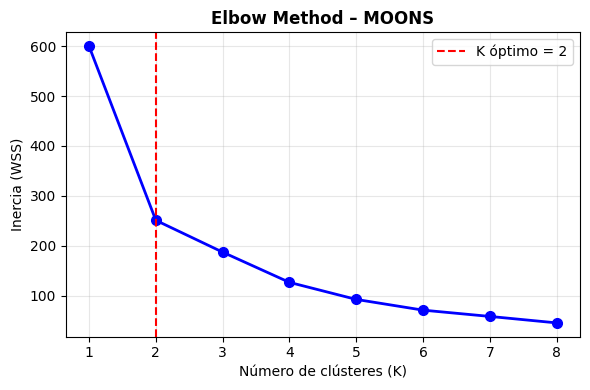

In [ ]:
inertias = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).inertia_
            for k in range(1, 9)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, 9), inertias, 'bo-', markersize=7, linewidth=2)
ax.axvline(2, color='red', linestyle='--', linewidth=1.5, label='K óptimo = 2')
ax.set_title("Elbow Method – MOONS", fontweight='bold')
ax.set_xlabel("Número de clústeres (K)")
ax.set_ylabel("Inercia (WSS)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Métricas Externas e Internas

In [ ]:
print(f"{'Modelo':<22} {'ARI':>7} {'V-Measure':>10} {'Silhouette':>11} {'DB-Index':>9}")
print("-" * 62)

resultados = []
for name, lbl in labels_dict.items():
    mask = lbl != -1
    ari  = adjusted_rand_score(y_true, lbl)
    vm   = v_measure_score(y_true, lbl)
    sil  = silhouette_score(X[mask], lbl[mask]) if len(set(lbl[mask])) >= 2 else float('nan')
    dbi  = davies_bouldin_score(X[mask], lbl[mask]) if len(set(lbl[mask])) >= 2 else float('nan')
    resultados.append((name, ari, vm, sil, dbi))
    print(f"{name:<22} {ari:>7.4f} {vm:>10.4f} {sil:>11.4f} {dbi:>9.4f}")


Modelo                     ARI  V-Measure  Silhouette  DB-Index
--------------------------------------------------------------
KMeans                  0.4790     0.3819      0.4936    0.8056
DBSCAN                  1.0000     1.0000      0.3803    1.0252
SpectralClustering      0.7619     0.6596      0.4563    0.8665


### Comparación visual de métricas

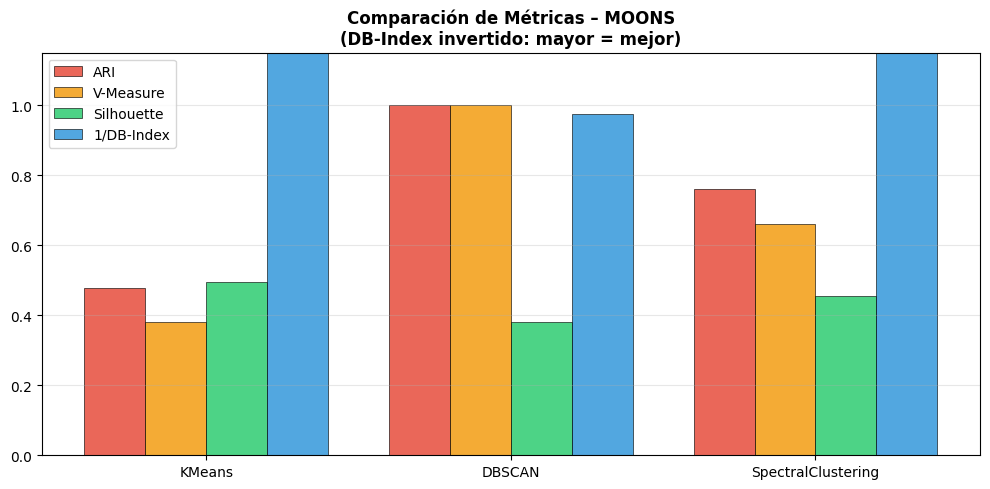

In [ ]:
import numpy as np

nombres   = [r[0] for r in resultados]
ari_vals  = [r[1] for r in resultados]
vm_vals   = [r[2] for r in resultados]
sil_vals  = [r[3] for r in resultados]
dbi_vals  = [1/r[4] if not np.isnan(r[4]) else 0 for r in resultados]  # invertido

x     = np.arange(len(nombres))
width = 0.2
colors_bar = ['#E74C3C', '#F39C12', '#2ECC71', '#3498DB']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 1.5*width, ari_vals,  width, label='ARI',           color=colors_bar[0], alpha=0.85, edgecolor='k', linewidth=0.5)
ax.bar(x - 0.5*width, vm_vals,   width, label='V-Measure',     color=colors_bar[1], alpha=0.85, edgecolor='k', linewidth=0.5)
ax.bar(x + 0.5*width, sil_vals,  width, label='Silhouette',    color=colors_bar[2], alpha=0.85, edgecolor='k', linewidth=0.5)
ax.bar(x + 1.5*width, dbi_vals,  width, label='1/DB-Index',    color=colors_bar[3], alpha=0.85, edgecolor='k', linewidth=0.5)

ax.set_xticks(x); ax.set_xticklabels(nombres, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title("Comparación de Métricas – MOONS\n(DB-Index invertido: mayor = mejor)",
             fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### Tabla resumen de métricas

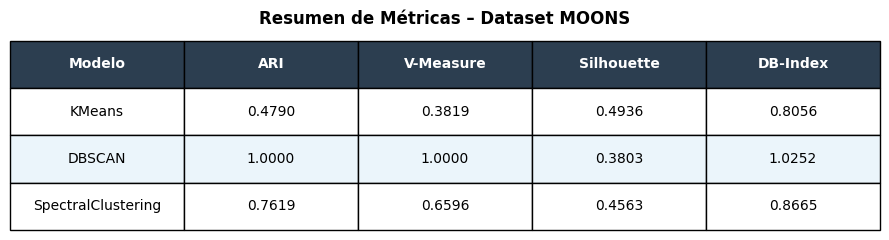

In [ ]:
fig, ax = plt.subplots(figsize=(9, 2.5))
ax.axis('off')

rows = [[n, f"{a:.4f}", f"{v:.4f}",
         f"{s:.4f}" if not np.isnan(s) else "N/A",
         f"{d:.4f}" if not np.isnan(d) else "N/A"]
        for n, a, v, s, d in resultados]

tbl = ax.table(cellText=rows,
               colLabels=['Modelo', 'ARI', 'V-Measure', 'Silhouette', 'DB-Index'],
               cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EBF5FB')

plt.title("Resumen de Métricas – Dataset MOONS", fontweight='bold', pad=12)
plt.tight_layout()
plt.show()
